In [ ]:
ARCH  = 'MAL'   # MAC | MAG | MAL | LMM
LABEL = 'QCD'   # QED | QCD

In [ ]:
# Cell 1 — Installs
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'einops', 'editdistance', '--quiet'], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'einops', 'editdistance', '--quiet'], returncode=0)

In [ ]:
# Cell 2 — Imports
import os, re, math, random, pickle, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
from collections import OrderedDict
from tqdm.auto import tqdm
import editdistance
import json

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
OUT_DIR   = './eval_results'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Device : {DEVICE}')
print(f'ARCH   : {ARCH}   LABEL : {LABEL}')

Device : cuda
ARCH   : MAL   LABEL : QCD


In [ ]:
# Cell 3 — Vocabulary class (needed before pkl load)
class AmplitudeTokenizer:
    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace
        if special_symbols is None:
            self.special_symbols = ['<PAD>','<UNK>','<BOS>','<EOS>',
                                     '<SEP>','<TERM0>','<TERM1>']
        else:
            self.special_symbols = special_symbols
        self.index_pool          = [f'INDEX_{i}'  for i in range(index_pool_size)]
        self.particle_index_pool = [f'PINDEX_{i}' for i in range(index_pool_size)]
        self.pattern_particle = re.compile(
            r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pattern_num_123  = re.compile(
            r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')

    @staticmethod
    def remove_whitespace(text): return re.sub(r'\s+', '', text)
    @staticmethod
    def split_expression(text):  return re.split(r' ', text)

    def normalize_indices(self, text):
        if not self.to_replace: return text
        text = self.remove_whitespace(text)
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r's_(\d+)', r'MOMENTUM_\1', text)
        text = text.replace('\\\\','\\').replace('\\',' \\ ').replace('%',' % ')
        index_matches = list(OrderedDict.fromkeys(self.pattern_num_123.findall(text)))
        index_iter = iter(self.index_pool); index_mapping = {}
        for m in index_matches:
            try:    index_mapping[m] = next(index_iter)
            except StopIteration: raise RuntimeError('INDEX pool exhausted')
        for old, new in sorted(index_mapping.items(),
                                key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)
        particle_matches = list(OrderedDict.fromkeys(
            m.group('target') for m in
            sorted(self.pattern_particle.finditer(text), key=lambda m: m.start())))
        particle_iter = iter(self.particle_index_pool); particle_mapping = {}
        for m in particle_matches:
            try:    particle_mapping[m] = next(particle_iter)
            except StopIteration: raise RuntimeError('PINDEX pool exhausted')
        for old, new in sorted(particle_mapping.items(),
                                key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)
        return text

    def tokenize_amplitude(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text)
        text = text.replace('(*)',' CONJ ').replace('(theta_W)','_theta_W')
        text = text.replace('\\\\','\\').replace('\\',' \\ ').replace('%',' % ')
        for s in ['/','+','-','*',',','^','%','}','(',')',  '=','[',']']:
            text = text.replace(s, f' {s} ')
        text = text.replace('_PINDEX','_ PINDEX').replace('_INDEX','_ INDEX')
        text = text.replace('reg_prop',' reg_prop ')
        text = re.sub(r' {2,}',' ',text).strip()
        return [x for x in self.split_expression(text) if x]

    def tokenize_squared(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text)
        text = text.replace('(theta_W)','_theta_W')
        for s in ['/','+','-','*',',','^','%','}','(',')',  '=','[',']']:
            text = text.replace(s, f' {s} ')
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)
        text = text.replace('reg_prop',' reg_prop ')
        text = re.sub(r' {2,}',' ',text).strip()
        return [x for x in self.split_expression(text) if x]


class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3,
                 sep_idx=4, term_idx=None):
        if term_idx is None: term_idx = [5, 6]
        tokens = list(tokens)
        for s in special_symbols:
            if s in tokens: tokens.remove(s)
        self.token_list   = special_symbols + tokens
        self.token_to_idx = {t: i for i,t in enumerate(self.token_list)}
        self.idx_to_token = {i: t for t,i in self.token_to_idx.items()}
        self.pad_idx=pad_idx; self.unk_idx=unk_idx
        self.bos_idx=bos_idx; self.eos_idx=eos_idx
        self.sep_idx=sep_idx; self.term_idx=term_idx
        self.pad_tok=special_symbols[pad_idx]; self.unk_tok=special_symbols[unk_idx]
        self.bos_tok=special_symbols[bos_idx]; self.eos_tok=special_symbols[eos_idx]
        self.sep_tok=special_symbols[sep_idx]
        self.special_indices = set(self.token_to_idx[s] for s in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]
    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(i, self.unk_tok) for i in indices]
        return [self.idx_to_token.get(i, self.unk_tok) for i in indices
                if i not in self.special_indices or i == self.sep_idx]
    def __len__(self):       return len(self.token_list)
    def __getitem__(self, x):
        if isinstance(x, int): return self.idx_to_token.get(x, self.unk_tok)
        return self.token_to_idx.get(x, self.unk_idx)
    def tokens(self):        return self.token_list

print('Vocabulary defined.')

Vocabulary defined.


In [ ]:
# Cell 4 — Load pkl and extract splits for the chosen LABEL
PKL_PATH = '/content/drive/MyDrive/Datasets/processed_data.pkl'

with open(PKL_PATH, 'rb') as f:
    PKL = pickle.load(f)

src_vocab = PKL[LABEL.lower()]['src_vocab']
tgt_vocab = PKL[LABEL.lower()]['tgt_vocab']
SRC_VS    = len(src_vocab)
TGT_VS    = len(tgt_vocab)

# ── Build DataFrames with half-splits ────────────────────────────────────────
def records_to_df(records):
    rows = []
    for r in records:
        amp_toks = r.get('amp_tokens', [])
        sq_toks  = r.get('sq_tokens',  [])
        mid_a    = max(1, len(amp_toks) // 2)
        mid_s    = max(1, len(sq_toks)  // 2)
        rows.append({
            'amp_tokens'  : amp_toks,
            'sq_tokens'   : sq_toks,
            'amp_ids'     : r.get('amp_ids', [BOS_IDX, EOS_IDX]),
            'sq_ids'      : r.get('sq_ids',  [BOS_IDX, EOS_IDX]),
            'amp_h1_toks' : amp_toks[:mid_a],
            'sq_h1_toks'  : sq_toks[:mid_s],
            'sq_h2_toks'  : sq_toks[mid_s:],
        })
    return pd.DataFrame(rows)

label_key   = LABEL.lower()
train_df    = records_to_df(PKL[label_key]['train'])
val_df      = records_to_df(PKL[label_key]['val'])
test_df     = records_to_df(PKL[label_key]['test'])

# ── Re-encode with this label's vocab to ensure no OOV ───────────────────────
def recode_df(df, sv, tv, src_max, tgt_max):
    new_a, new_s = [], []
    for _, row in df.iterrows():
        a = [BOS_IDX] + sv.encode(list(row['amp_tokens']))[:src_max-2] + [EOS_IDX]
        s = [BOS_IDX] + tv.encode(list(row['sq_tokens'])) [:tgt_max-2] + [EOS_IDX]
        new_a.append(a); new_s.append(s)
    df = df.copy(); df['amp_ids'] = new_a; df['sq_ids'] = new_s
    return df

# Compute max lengths from this label's training data only
all_amp = [r['amp_tokens'] for r in PKL[label_key]['train']]
all_sq  = [r['sq_tokens']  for r in PKL[label_key]['train']]
SRC_MAX = min(int(np.percentile([len(x) for x in all_amp], 97)) + 4, 512)
TGT_MAX = min(int(np.percentile([len(x) for x in all_sq],  97)) + 4, 512)
print(f'SRC_MAX={SRC_MAX}  TGT_MAX={TGT_MAX}')
print(f'src_vocab={SRC_VS}  tgt_vocab={TGT_VS}')

train_df = recode_df(train_df, src_vocab, tgt_vocab, SRC_MAX, TGT_MAX)
val_df   = recode_df(val_df,   src_vocab, tgt_vocab, SRC_MAX, TGT_MAX)
test_df  = recode_df(test_df,  src_vocab, tgt_vocab, SRC_MAX, TGT_MAX)

# Verify no OOV
for name, series, vs in [('src', train_df['amp_ids'], SRC_VS),
                          ('tgt', train_df['sq_ids'],  TGT_VS)]:
    mx = max(max(x) for x in series)
    assert mx < vs, f'OOV! max_id={mx} >= vocab={vs}'
    print(f'  {LABEL} train {name}: max_id={mx}  vocab={vs}  OK')

SRC_MAX=512  TGT_MAX=512
src_vocab=179  tgt_vocab=67
  QCD train src: max_id=178  vocab=179  OK
  QCD train tgt: max_id=66  vocab=67  OK


In [ ]:
# ── RMSNorm ───────────────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / (x.pow(2).mean(-1, keepdim=True) + self.eps).sqrt() * self.weight


# ── RoPE ──────────────────────────────────────────────────────────────────────
class RoPE(nn.Module):
    def __init__(self, head_dim, max_seq=2048):
        super().__init__()
        inv = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer('inv_freq', inv)
        self._build(max_seq)

    def _build(self, L, device=None, dtype=None):
        inv = self.inv_freq.to(device) if device else self.inv_freq
        pos = torch.arange(L, device=inv.device, dtype=torch.float32)
        f   = torch.outer(pos, inv.float())
        cos, sin = f.cos(), f.sin()
        if dtype: cos, sin = cos.to(dtype), sin.to(dtype)
        self.register_buffer('cos_c', cos, persistent=False)
        self.register_buffer('sin_c', sin, persistent=False)

    def forward(self, q, k):
        S = q.shape[2]
        if S > self.cos_c.shape[0] or self.cos_c.device != q.device or self.cos_c.dtype != q.dtype:
            self._build(max(S, self.cos_c.shape[0]), q.device, q.dtype)
        cos = self.cos_c[:S].unsqueeze(0).unsqueeze(0)
        sin = self.sin_c[:S].unsqueeze(0).unsqueeze(0)
        def rot(x):
            x1, x2 = x[..., ::2], x[..., 1::2]
            return torch.stack([x1*cos - x2*sin, x1*sin + x2*cos], -1).flatten(-2)
        return rot(q), rot(k)


# ── MemoryMLP ─────────────────────────────────────────────────────────────────
class MemoryMLP(nn.Module):
    def __init__(self, dim, num_layers=1, hidden_mult=1.0, init_std=0.02):
        super().__init__()
        H = int(dim * hidden_mult)
        if num_layers == 1:
            layers = [nn.Linear(dim, dim, bias=False)]
        else:
            layers = ([nn.Linear(dim, H, bias=False)] +
                      [nn.Linear(H, H, bias=False) for _ in range(num_layers - 2)] +
                      [nn.Linear(H, dim, bias=False)])
        self.layers = nn.ModuleList(layers)
        for l in self.layers:
            nn.init.normal_(l.weight, std=init_std)

    def forward(self, x):
        h = x
        for i, l in enumerate(self.layers):
            h = l(h)
            if i < len(self.layers) - 1: h = F.silu(h)
        return h

    def get_weights(self): return [l.weight.data.clone() for l in self.layers]
    def set_weights(self, ws):
        for l, w in zip(self.layers, ws): l.weight.data.copy_(w)
    def compute_loss(self, k, v): return F.mse_loss(self.forward(k), v)


# ── NeuralLTM (Titans long-term memory — Equations 21-25 of arXiv:2501.00663) ─
class NeuralLTM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.cfg      = cfg
        self.proj_k   = nn.Linear(dim, dim, bias=False)
        self.proj_v   = nn.Linear(dim, dim, bias=False)
        self.proj_q   = nn.Linear(dim, dim, bias=False)
        self.proj_out = nn.Linear(dim, dim, bias=False)
        self.memory   = MemoryMLP(dim, cfg['num_memory_layers'],
                                   cfg['memory_hidden_mult'], cfg['init_std'])
        self.gate_decay = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.gate_lr    = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.gate_mom   = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        for m in [self.proj_k, self.proj_v, self.proj_q, self.proj_out]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def init_state(self, device):
        return {'weights':  [w.clone().to(device) for w in self.memory.get_weights()],
                'momentum': [torch.zeros_like(w).to(device) for w in self.memory.get_weights()]}

    def retrieve(self, x, state):
        self.memory.set_weights(state['weights'])
        q = F.normalize(F.silu(self.proj_q(x)), p=2, dim=-1)
        return self.proj_out(self.memory(q))

    def forward(self, x, state):
        self.memory.set_weights(state['weights'])
        k = F.normalize(F.silu(self.proj_k(x)), p=2, dim=-1)
        v = F.silu(self.proj_v(x))
        q = F.normalize(F.silu(self.proj_q(x)), p=2, dim=-1)
        retrieved = self.memory(q)
        xm    = x.mean(1, keepdim=True)
        alpha = self.gate_decay(xm).mean() * self.cfg['memory_decay']
        theta = self.gate_lr(xm).mean()    * self.cfg['memory_lr']
        eta   = self.gate_mom(xm).mean()   * self.cfg['memory_momentum']
        with torch.enable_grad():
            for p in self.memory.parameters(): p.requires_grad_(True)
            loss  = self.memory.compute_loss(k.detach(), v.detach())
            grads = torch.autograd.grad(loss, list(self.memory.parameters()),
                                        create_graph=False, allow_unused=True)
            for p in self.memory.parameters(): p.requires_grad_(False)
        grads     = [g if g is not None else torch.zeros_like(p)
                     for g, p in zip(grads, self.memory.parameters())]
        new_mom   = [eta*m - theta*g for m, g in zip(state['momentum'], grads)]
        new_wts   = [(1-alpha)*w + s for w, s in zip(state['weights'], new_mom)]
        new_state = {'weights':  [w.detach() for w in new_wts],
                     'momentum': [m.detach() for m in new_mom]}
        return self.proj_out(retrieved), new_state


# ── PersistentMemory ──────────────────────────────────────────────────────────
class PersistentMemory(nn.Module):
    def __init__(self, n, dim, std=0.02):
        super().__init__()
        self.tokens = nn.Parameter(torch.randn(n, dim) * std) if n > 0 else None
    def forward(self, B):
        return self.tokens.unsqueeze(0).expand(B, -1, -1) if self.tokens is not None else None


# ── FFN (SwiGLU) ──────────────────────────────────────────────────────────────
class FFN(nn.Module):
    def __init__(self, dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.gate = nn.Linear(dim, ffn_dim, bias=False)
        self.up   = nn.Linear(dim, ffn_dim, bias=False)
        self.down = nn.Linear(ffn_dim, dim, bias=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        return self.down(self.drop(F.silu(self.gate(x)) * self.up(x)))


# ── CausalMHA ─────────────────────────────────────────────────────────────────
class CausalMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim, nh, hd = cfg['dim'], cfg['num_heads'], cfg['head_dim']
        self.nh, self.hd, self.scale = nh, hd, hd**-0.5
        self.dp   = cfg['dropout']
        self.Wq   = nn.Linear(dim, dim, bias=False)
        self.Wk   = nn.Linear(dim, dim, bias=False)
        self.Wv   = nn.Linear(dim, dim, bias=False)
        self.Wo   = nn.Linear(dim, dim, bias=False)
        self.rope = RoPE(hd, cfg['max_seq_len']) if cfg['use_rope'] else None
        for m in [self.Wq, self.Wk, self.Wv, self.Wo]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def forward(self, x, extra_prefix=None):
        B, S, D = x.shape
        pre  = 0
        if extra_prefix is not None:
            full = torch.cat([extra_prefix, x], dim=1); pre = extra_prefix.shape[1]
        else:
            full = x
        L = full.shape[1]
        q = self.Wq(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        k = self.Wk(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        v = self.Wv(full).view(B, L, self.nh, self.hd).transpose(1, 2)
        if self.rope: q, k = self.rope(q, k)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
              dropout_p=self.dp if self.training else 0.0,
              is_causal=True, scale=self.scale)
        out = out.transpose(1, 2).reshape(B, L, D)
        return self.Wo(out)[:, pre:]


# ── SlidingWindowMHA ──────────────────────────────────────────────────────────
class SlidingWindowMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim, nh, hd = cfg['dim'], cfg['num_heads'], cfg['head_dim']
        self.nh, self.hd, self.scale = nh, hd, hd**-0.5
        self.dp = cfg['dropout']
        self.W  = cfg['window_size']
        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.Wo = nn.Linear(dim, dim, bias=False)
        self.rope = RoPE(hd, cfg['max_seq_len']) if cfg['use_rope'] else None
        for m in [self.Wq, self.Wk, self.Wv, self.Wo]:
            nn.init.normal_(m.weight, std=cfg['init_std'])

    def forward(self, x):
        B, S, D = x.shape
        q = self.Wq(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        k = self.Wk(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        v = self.Wv(x).view(B, S, self.nh, self.hd).transpose(1, 2)
        if self.rope: q, k = self.rope(q, k)
        mask = torch.full((S, S), float('-inf'), device=x.device, dtype=x.dtype)
        for i in range(S):
            mask[i, max(0, i-self.W+1):i+1] = 0.0
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask,
              dropout_p=self.dp if self.training else 0.0, scale=self.scale)
        out = out.transpose(1, 2).reshape(B, S, D)
        return self.Wo(out)


# ── Shared standard Transformer decoder ──────────────────────────────────────
def build_decoder(cfg):
    dim, nh, fd, dr = cfg['dim'], cfg['num_heads'], cfg['ffn_dim'], cfg['dropout']
    dec = nn.TransformerDecoderLayer(d_model=dim, nhead=nh, dim_feedforward=fd,
                                      dropout=dr, batch_first=True, norm_first=True)
    return nn.TransformerDecoder(dec, num_layers=cfg['num_decoder_layers'])


print('Shared building blocks defined.')


Shared building blocks defined.


In [ ]:
# Cell 5 — Config (per-label vocab sizes, auto-set)
CFG = {
    'dim'                   : 128,
    'num_heads'             : 8,
    'head_dim'              : 16,
    'ffn_mult'              : 4.0,
    'ffn_dim'               : 512,
    'num_encoder_layers'    : 2,
    'num_decoder_layers'    : 2,
    'num_memory_layers'     : 1,
    'num_persistent_tokens' : 4,
    'chunk_size'            : 64,
    'memory_hidden_mult'    : 1.0,
    'memory_lr'             : 0.05,
    'memory_momentum'       : 0.9,
    'memory_decay'          : 0.01,
    'window_size'           : 64,
    'miras_router_dim'      : 32,
    'dropout'               : 0.1,
    'label_smoothing'       : 0.1,
    'use_rope'              : True,
    'max_seq_len'           : 600,
    'init_std'              : 0.02,
    'src_vocab_size'        : SRC_VS,   # set from this label's vocab
    'tgt_vocab_size'        : TGT_VS,   # set from this label's vocab
    'src_max_len'           : SRC_MAX,
    'tgt_max_len'           : TGT_MAX,
    'batch_size'            : 4,
    'grad_accum_steps'      : 4,
    'epochs'                : 120,
    'optimizer_lr'          : 3e-4,
    'end_lr'                : 1e-6,
    'weight_decay'          : 1e-4,
    'warmup_ratio'          : 0.1,
    'clip_grad_norm'        : 1.0,
}
CKPT_DIR = f'./ckpt/{ARCH}_{LABEL}'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'Config ready. src_vocab={SRC_VS}  tgt_vocab={TGT_VS}')

Config ready. src_vocab=179  tgt_vocab=67


In [ ]:
class MiRASRouter(nn.Module):

    def __init__(self, dim, router_dim):
        super().__init__()
        self.w1 = nn.Linear(dim, router_dim, bias=False)
        self.w2 = nn.Linear(router_dim, 1,   bias=False)
        nn.init.normal_(self.w1.weight, std=0.02)
        nn.init.zeros_(self.w2.weight)

    def forward(self, x, mem_out, attn_out):
        g = torch.sigmoid(self.w2(F.silu(self.w1(x))))  # (B, S, 1)
        return g * mem_out + (1 - g) * attn_out


print('MiRASRouter defined.')


MiRASRouter defined.


In [ ]:
# MAC + MiRAS   (Memory as Context — memory retrieved and prepended as prefix)
class MACMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory     = NeuralLTM(cfg)
        self.persistent = PersistentMemory(cfg['num_persistent_tokens'], dim, cfg['init_std'])
        self.attn       = CausalMHA(cfg)
        self.ffn        = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1      = RMSNorm(dim)
        self.norm2      = RMSNorm(dim)
        self.norm_mem   = RMSNorm(dim)
        self.router     = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop       = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        B = x.shape[0]
        if state is None: state = self.memory.init_state(x.device)
        # Memory path: retrieve
        h_t    = self.memory.retrieve(x, state)
        h_n    = self.norm_mem(h_t)
        # Attention path: memory + persistent tokens as prefix context
        p      = self.persistent(B)
        prefix = torch.cat([p, h_n], dim=1) if p is not None else h_n
        attn_out = self.attn(self.norm1(x), extra_prefix=prefix)
        # MiRAS router blends memory retrieval and attention output
        y      = x + self.drop(self.router(x, h_n[:, :x.shape[1]], attn_out))
        # Update memory
        _, ns  = self.memory(y, state=state)
        out    = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# MAG + MiRAS   (Memory as Gate — gate-blend of attn and memory)
class MAGMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory   = NeuralLTM(cfg)
        self.attn     = SlidingWindowMHA(cfg)
        self.ffn      = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1    = RMSNorm(dim)
        self.norm2    = RMSNorm(dim)
        self.norm_mem = RMSNorm(dim)
        # MiRAS router replaces the fixed 50/50 gate with a learned per-token gate
        self.router   = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop     = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        attn_out        = self.attn(self.norm1(x))
        mem_out, ns     = self.memory(x, state)
        mem_out         = self.norm_mem(mem_out)
        # MiRAS router: dynamic per-token blend
        y   = x + self.drop(self.router(x, mem_out, attn_out))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# MAL + MiRAS   (Memory as Layer — memory preprocesses input, then attn)
class MALMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory   = NeuralLTM(cfg)
        self.attn     = SlidingWindowMHA(cfg)
        self.ffn      = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1    = RMSNorm(dim)
        self.norm2    = RMSNorm(dim)
        self.norm_mem = RMSNorm(dim)
        # MiRAS router blends raw input (before preprocessing) and memory-preprocessed
        self.router   = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop     = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        # Memory preprocessing
        mem_out, ns = self.memory(x, state)
        # MiRAS router blends original input (attn path) and memory output
        x_hat = x + self.drop(self.router(x, self.norm_mem(mem_out), x))
        # Sliding-window attention on blended input
        y   = x_hat + self.drop(self.attn(self.norm1(x_hat)))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# LMM + MiRAS   (Long-term Memory Module — memory only, no attention)
# MiRAS router here blends memory output with the original input (identity path)
class LMMMiRASBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        dim = cfg['dim']
        self.memory = NeuralLTM(cfg)
        self.ffn    = FFN(dim, cfg['ffn_dim'], cfg['dropout'])
        self.norm1  = RMSNorm(dim)
        self.norm2  = RMSNorm(dim)
        # Router blends memory output and identity (input pass-through)
        self.router = MiRASRouter(dim, cfg['miras_router_dim'])
        self.drop   = nn.Dropout(cfg['dropout'])

    def forward(self, x, state=None):
        if state is None: state = self.memory.init_state(x.device)
        mem_out, ns = self.memory(self.norm1(x), state)
        # MiRAS: blend memory output vs. input identity
        y   = x + self.drop(self.router(x, mem_out, x))
        out = y + self.drop(self.ffn(self.norm2(y)))
        return out, ns


# ── Generic chunked encoder (wraps any block type) ────────────────────────────
class TitansEncoder(nn.Module):
    def __init__(self, cfg, block_cls):
        super().__init__()
        self.chunk  = cfg['chunk_size']
        self.embed  = nn.Embedding(cfg['src_vocab_size'], cfg['dim'], padding_idx=PAD_IDX)
        self.blocks = nn.ModuleList([block_cls(cfg) for _ in range(cfg['num_encoder_layers'])])
        self.norm   = RMSNorm(cfg['dim'])
        nn.init.normal_(self.embed.weight, std=cfg['init_std'])

    def forward(self, src):
        x = self.embed(src)
        outs, states = [], [None] * len(self.blocks)
        for s in range(0, x.shape[1], self.chunk):
            chunk = x[:, s:s+self.chunk]
            ns = []
            for i, blk in enumerate(self.blocks):
                chunk, nsi = blk(chunk, state=states[i])
                ns.append(nsi)
            states = ns
            outs.append(chunk)
        return self.norm(torch.cat(outs, dim=1))


# ── Generic Seq2Seq model ─────────────────────────────────────────────────────
class TitansMiRASSeq2Seq(nn.Module):
    """Encoder: Titans block (MAC/MAG/MAL/LMM) + MiRAS router. Decoder: standard Transformer."""
    def __init__(self, cfg, block_cls):
        super().__init__()
        self.cfg       = cfg
        self.encoder   = TitansEncoder(cfg, block_cls)
        self.tgt_embed = nn.Embedding(cfg['tgt_vocab_size'], cfg['dim'], padding_idx=PAD_IDX)
        nn.init.normal_(self.tgt_embed.weight, std=cfg['init_std'])
        self.decoder   = build_decoder(cfg)
        self.norm_out  = RMSNorm(cfg['dim'])
        self.head      = nn.Linear(cfg['dim'], cfg['tgt_vocab_size'], bias=False)
        self.head.weight = self.tgt_embed.weight   # weight tying

    def forward(self, src, tgt, src_pad, tgt_pad):
        mem     = self.encoder(src)
        tgt_emb = self.tgt_embed(tgt)
        T       = tgt.shape[1]
        causal  = torch.triu(torch.ones(T, T, device=src.device), diagonal=1).bool()
        dec_out = self.decoder(tgt=tgt_emb, memory=mem,
                               tgt_mask=causal,
                               tgt_key_padding_mask=~tgt_pad,
                               memory_key_padding_mask=~src_pad)
        return self.head(self.norm_out(dec_out))

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, tgt, memory, src_pad):
        T       = tgt.shape[1]
        causal  = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).bool()
        tgt_emb = self.tgt_embed(tgt)
        dec_out = self.decoder(tgt=tgt_emb, memory=memory,
                               tgt_mask=causal,
                               memory_key_padding_mask=~src_pad)
        return self.head(self.norm_out(dec_out))


# ── Architecture registry ─────────────────────────────────────────────────────
ARCH_MAP = {
    'MAC': MACMiRASBlock,
    'MAG': MAGMiRASBlock,
    'MAL': MALMiRASBlock,
    'LMM': LMMMiRASBlock,
}

def build_model(arch_name, cfg):
    assert arch_name in ARCH_MAP, f'Unknown arch: {arch_name}'
    return TitansMiRASSeq2Seq(cfg, ARCH_MAP[arch_name]).to(DEVICE)


# ── Param count check (must be < 10M each) ────────────────────────────────────
print('Architecture param counts:')
for arch in ['MAC', 'MAG', 'MAL', 'LMM']:
    m = build_model(arch, CFG)
    tot = sum(p.numel() for p in m.parameters())
    enc = sum(p.numel() for p in m.encoder.parameters())
    dec = sum(p.numel() for p in m.decoder.parameters())
    print(f'  {arch}  total={tot:,} ({tot/1e6:.2f}M)  enc={enc:,}  dec={dec:,}')
    assert tot < 10_000_000, f'{arch} exceeds 10M params!'
    del m


Architecture param counts:
  MAC  total=1,358,144 (1.36M)  enc=820,288  dec=529,152
  MAG  total=1,357,120 (1.36M)  enc=819,264  dec=529,152
  MAL  total=1,357,120 (1.36M)  enc=819,264  dec=529,152
  LMM  total=1,225,792 (1.23M)  enc=687,936  dec=529,152


In [ ]:
# Cell 7 — Dataset + collate
def collate_fn(batch):
    s = pad_sequence([b[0] for b in batch], padding_value=PAD_IDX, batch_first=True)
    t = pad_sequence([b[1] for b in batch], padding_value=PAD_IDX, batch_first=True)
    return s, t

class PreEncodedDataset(Dataset):
    def __init__(self, df, src_max, tgt_max):
        self.srcs = df['amp_ids'].tolist()
        self.tgts = df['sq_ids'].tolist()
        self.sm, self.tm = src_max, tgt_max
    def __len__(self): return len(self.srcs)
    def __getitem__(self, i):
        s = torch.tensor(self.srcs[i][:self.sm], dtype=torch.long)
        t = torch.tensor(self.tgts[i][:self.tm], dtype=torch.long)
        return s, t

print('Dataset defined.')

Dataset defined.


# Cell 8 — Load pretrained checkpoints with size-mismatch handling

In [ ]:
# Cell 8 — Load pretrained checkpoints with size-mismatch handling
PRETRAINED_ENC = '/content/drive/MyDrive/Datasets/pretrained_encoder.pth'
PRETRAINED_EMB = '/content/drive/MyDrive/Datasets/pretrained_tgt_embed.pth'

model = build_model(ARCH, CFG)

# ── Load encoder ──────────────────────────────────────────────────────────────
if os.path.exists(PRETRAINED_ENC):
    pkg  = torch.load(PRETRAINED_ENC, map_location=DEVICE)
    sd   = pkg['state'] if 'state' in pkg else pkg

    # Remove any key whose shape does not match the current model
    model_sd     = model.encoder.state_dict()
    filtered_sd  = {}
    skipped      = []
    for k, v in sd.items():
        if k in model_sd and model_sd[k].shape == v.shape:
            filtered_sd[k] = v
        else:
            skipped.append(f'  SKIP encoder [{k}]: ckpt={v.shape} vs model={model_sd.get(k, "missing")}')

    model.encoder.load_state_dict(filtered_sd, strict=False)
    print(f'Encoder loaded. Transferred {len(filtered_sd)}/{len(sd)} keys.')
    if skipped:
        print('  Skipped due to size mismatch:')
        for s in skipped: print(s)
else:
    print(f'Encoder checkpoint not found: {PRETRAINED_ENC}')

# ── Load target embedding ─────────────────────────────────────────────────────
if os.path.exists(PRETRAINED_EMB):
    emb_sd       = torch.load(PRETRAINED_EMB, map_location=DEVICE)
    model_emb_sd = model.tgt_embed.state_dict()
    filtered_emb = {}
    skipped_emb  = []
    for k, v in emb_sd.items():
        if k in model_emb_sd and model_emb_sd[k].shape == v.shape:
            filtered_emb[k] = v
        else:
            skipped_emb.append(
                f'  SKIP tgt_embed [{k}]: ckpt={v.shape} vs model={model_emb_sd.get(k, "missing")}')

    model.tgt_embed.load_state_dict(filtered_emb, strict=False)
    print(f'tgt_embed loaded. Transferred {len(filtered_emb)}/{len(emb_sd)} keys.')
    if skipped_emb:
        print('  Skipped due to size mismatch:')
        for s in skipped_emb: print(s)
else:
    print(f'tgt_embed checkpoint not found: {PRETRAINED_EMB}')

total = sum(p.numel() for p in model.parameters())
print(f'\nModel : {ARCH}  Label : {LABEL}')
print(f'Params: {total:,} ({total/1e6:.2f}M)')
print(f'src_vocab={CFG["src_vocab_size"]}  tgt_vocab={CFG["tgt_vocab_size"]}')

Encoder loaded. Transferred 49/52 keys.
  Skipped due to size mismatch:
  SKIP encoder [embed.weight]: ckpt=torch.Size([97, 128]) vs model=tensor([[ 0.0138,  0.0258, -0.0105,  ..., -0.0056, -0.0258,  0.0165],
        [-0.0115,  0.0290, -0.0131,  ...,  0.0033,  0.0049, -0.0139],
        [ 0.0152,  0.0009,  0.0093,  ..., -0.0163,  0.0136,  0.0202],
        ...,
        [-0.0072,  0.0290, -0.0125,  ..., -0.0423,  0.0153,  0.0209],
        [-0.0236,  0.0362,  0.0310,  ...,  0.0084,  0.0008,  0.0099],
        [-0.0053, -0.0130,  0.0245,  ...,  0.0050, -0.0031, -0.0388]],
       device='cuda:0')
  SKIP encoder [blocks.0.persistent.tokens]: ckpt=torch.Size([4, 128]) vs model=missing
  SKIP encoder [blocks.1.persistent.tokens]: ckpt=torch.Size([4, 128]) vs model=missing
tgt_embed loaded. Transferred 0/1 keys.
  Skipped due to size mismatch:
  SKIP tgt_embed [weight]: ckpt=torch.Size([43, 128]) vs model=tensor([[ 0.0328, -0.0121, -0.0192,  ...,  0.0079, -0.0038, -0.0071],
        [-0.0055,  0.0

# Cell 9 — Fine-tune and save

In [ ]:
# Cell 9 — Fine-tune and save
def fine_tune_single(model, n_epochs=None):
    n_epochs   = n_epochs or CFG['epochs']
    batch_size = CFG['batch_size']
    accum      = CFG['grad_accum_steps']
    lr         = CFG['optimizer_lr']
    tgt_vs     = CFG['tgt_vocab_size']

    ds_tr = PreEncodedDataset(train_df, SRC_MAX, TGT_MAX)
    ds_va = PreEncodedDataset(val_df,   SRC_MAX, TGT_MAX)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,
                       collate_fn=collate_fn, num_workers=2,
                       pin_memory=True, drop_last=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False,
                       collate_fn=collate_fn, num_workers=2, pin_memory=True)

    crit     = nn.CrossEntropyLoss(ignore_index=PAD_IDX,
                                    label_smoothing=CFG['label_smoothing'])
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')
    opt      = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=CFG['weight_decay'], eps=1e-9)
    scaler   = GradScaler()

    total_steps = (len(dl_tr) // accum) * n_epochs
    warm_steps  = max(1, int(CFG['warmup_ratio'] * total_steps))

    def lam(step):
        if step < warm_steps:
            return max(1e-8, step / warm_steps)
        p = (step - warm_steps) / max(1, total_steps - warm_steps)
        return max(CFG['end_lr'] / lr, 0.5 * (1 + math.cos(math.pi * p)))

    sched    = LambdaLR(opt, lam)
    ckpt_p   = os.path.join(CKPT_DIR, 'best.pth')
    history  = {'tr_loss':[],'tr_ppl':[],'va_loss':[],'va_ppl':[],'va_tok_acc':[]}
    best_va  = float('inf'); best_ppl = float('inf')
    gs       = 0

    print(f'\n{"="*60}')
    print(f'  {ARCH} on {LABEL}  |  train={len(ds_tr)}  val={len(ds_va)}')
    print(f'  epochs={n_epochs}  eff_batch={batch_size*accum}  lr={lr}')
    print(f'{"="*60}')
    print(f'  {"ep":>5}  {"tr_loss":>8}  {"tr_ppl":>8}  '
          f'{"va_loss":>8}  {"va_ppl":>8}  {"tok_acc":>7}  {"lr":>9}')
    print(f'  {"-"*58}')

    for ep in range(n_epochs):
        model.train(); tl,tn,tkl,tkn = 0.,0,0.,0; opt.zero_grad()

        for si,(src,tgt) in enumerate(dl_tr):
            src,tgt  = src.to(DEVICE), tgt.to(DEVICE)
            src_pad  = src != PAD_IDX
            tgt_in   = tgt[:,:-1]; tgt_out = tgt[:,1:]
            tgt_pad  = tgt_in != PAD_IDX

            with autocast(device_type='cuda', dtype=DTYPE):
                logits = model(src, tgt_in, src_pad, tgt_pad)
                loss   = crit(logits.reshape(-1,tgt_vs),
                              tgt_out.reshape(-1)) / accum
            scaler.scale(loss).backward()

            if (si+1) % accum == 0:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), CFG['clip_grad_norm'])
                scaler.step(opt); scaler.update()
                opt.zero_grad(); sched.step(); gs += 1

            with torch.no_grad():
                tkl += crit_sum(logits.reshape(-1,tgt_vs),
                                tgt_out.reshape(-1)).item()
                tkn += (tgt_out != PAD_IDX).sum().item()
            tl += loss.item()*accum*src.size(0); tn += src.size(0)

        tr_loss = tl/max(tn,1)
        tr_ppl  = math.exp(min(tkl/max(tkn,1), 20))

        model.eval(); vl,vn,vc,vt,vkl,vkn = 0.,0,0,0,0.,0
        with torch.no_grad():
            for src,tgt in dl_va:
                src,tgt = src.to(DEVICE),tgt.to(DEVICE)
                src_pad = src!=PAD_IDX
                tgt_in  = tgt[:,:-1]; tgt_out = tgt[:,1:]
                tgt_pad = tgt_in!=PAD_IDX
                with autocast(device_type='cuda', dtype=DTYPE):
                    logits = model(src,tgt_in,src_pad,tgt_pad)
                    loss   = crit(logits.reshape(-1,tgt_vs), tgt_out.reshape(-1))
                    vkl   += crit_sum(logits.reshape(-1,tgt_vs),
                                      tgt_out.reshape(-1)).item()
                vkn += (tgt_out!=PAD_IDX).sum().item()
                msk  = tgt_out!=PAD_IDX
                vc  += (logits.argmax(-1)==tgt_out).masked_select(msk).sum().item()
                vt  += msk.sum().item()
                vl  += loss.item()*src.size(0); vn += src.size(0)

        va_loss = vl/max(vn,1)
        va_ppl  = math.exp(min(vkl/max(vkn,1),20))
        va_acc  = vc/max(vt,1)

        history['tr_loss'].append(tr_loss); history['tr_ppl'].append(tr_ppl)
        history['va_loss'].append(va_loss); history['va_ppl'].append(va_ppl)
        history['va_tok_acc'].append(va_acc)

        if va_loss < best_va:
            best_va = va_loss; best_ppl = va_ppl
            torch.save({'arch':ARCH,'label':LABEL,'cfg':CFG,
                        'model':model.state_dict(),
                        'va_loss':va_loss,'va_ppl':va_ppl,
                        'tr_ppl':tr_ppl,'va_tok_acc':va_acc,
                        'epoch':ep}, ckpt_p)

        if (ep+1)%10==0 or ep==0:
            star = ' ★' if va_loss==best_va else ''
            print(f'  {ep+1:5d}  {tr_loss:8.4f}  {tr_ppl:8.3f}'
                  f'  {va_loss:8.4f}  {va_ppl:8.3f}'
                  f'  {va_acc*100:6.1f}%'
                  f'  {opt.param_groups[0]["lr"]:9.2e}{star}')

    print(f'\n  Best va_loss={best_va:.4f}  va_ppl={best_ppl:.3f}')
    print(f'  Saved: {ckpt_p}')
    return history


history = fine_tune_single(model)


  MAL on QCD  |  train=187  val=23
  epochs=120  eff_batch=16  lr=0.0003
     ep   tr_loss    tr_ppl   va_loss    va_ppl  tok_acc         lr
  ----------------------------------------------------------
      1    4.1902    65.615    4.1102    60.287     4.2%   2.50e-05 ★
     10    2.2665     7.418    2.1458     6.449    57.0%   2.50e-04 ★
     20    1.6567     3.419    1.5855     3.172    67.4%   2.96e-04 ★
     30    1.4896     2.812    1.4091     2.578    73.3%   2.80e-04 ★
     40    1.3766     2.479    1.2805     2.218    78.6%   2.53e-04 ★
     50    1.2984     2.242    1.1939     1.988    82.6%   2.17e-04 ★
     60    1.2411     2.101    1.1496     1.874    83.9%   1.76e-04
     70    1.2069     2.011    1.1051     1.769    86.0%   1.33e-04 ★
     80    1.1734     1.936    1.0723     1.698    87.4%   9.06e-05 ★
     90    1.1524     1.874    1.0518     1.649    88.3%   5.36e-05
    100    1.1339     1.841    1.0353     1.613    88.9%   2.47e-05 ★
    110    1.1292     1.824    

#Below cells are for evaluation and testing


In [ ]:
# Checkpoint naming: {CKPT_ROOT}/{ARCH}_{LABEL}best.pth
# e.g. /content/drive/MyDrive/Datasets/ckpt/MAC_QEDbest.pth

CKPT_ROOT = '/content/drive/MyDrive/Datasets/ckpt'
ARCHS     = ['MAC', 'MAG', 'MAL', 'LMM']
LABELS    = ['QED', 'QCD']

# ── Vocabs and test DataFrames ────────────────────────────────────────────────
vocabs = {
    'QED': (PKL['qed']['src_vocab'], PKL['qed']['tgt_vocab']),
    'QCD': (PKL['qcd']['src_vocab'], PKL['qcd']['tgt_vocab']),
}

test_dfs = {
    'QED': records_to_df(PKL['qed']['test']),
    'QCD': records_to_df(PKL['qcd']['test']),
}

# ── Config builder ────────────────────────────────────────────────────────────
def build_cfg(label_name):
    label_key = label_name.lower()
    src_vocab = PKL[label_key]['src_vocab']
    tgt_vocab = PKL[label_key]['tgt_vocab']
    all_amp   = [r['amp_tokens'] for r in PKL[label_key]['train']]
    all_sq    = [r['sq_tokens']  for r in PKL[label_key]['train']]

    return {
        'dim'                   : 128,
        'num_heads'             : 8,
        'head_dim'              : 16,
        'ffn_mult'              : 4.0,
        'ffn_dim'               : 512,
        'num_encoder_layers'    : 2,
        'num_decoder_layers'    : 2,
        'num_memory_layers'     : 1,
        'num_persistent_tokens' : 4,
        'chunk_size'            : 64,
        'memory_hidden_mult'    : 1.0,
        'memory_lr'             : 0.05,
        'memory_momentum'       : 0.9,
        'memory_decay'          : 0.01,
        'window_size'           : 64,
        'miras_router_dim'      : 32,
        'dropout'               : 0.1,
        'label_smoothing'       : 0.1,
        'use_rope'              : True,
        'max_seq_len'           : 600,
        'init_std'              : 0.02,
        'batch_size'            : 4,
        'grad_accum_steps'      : 4,
        'epochs'                : 120,
        'optimizer_lr'          : 3e-4,
        'end_lr'                : 1e-6,
        'weight_decay'          : 1e-4,
        'warmup_ratio'          : 0.1,
        'clip_grad_norm'        : 1.0,
        'src_vocab_size'        : len(src_vocab),
        'tgt_vocab_size'        : len(tgt_vocab),
        'src_max_len'           : min(int(np.percentile(
                                      [len(x) for x in all_amp], 97))+4, 512),
        'tgt_max_len'           : min(int(np.percentile(
                                      [len(x) for x in all_sq],  97))+4, 512),
    }

# ── Scan what actually exists so you know exactly what files are found ────────
print('Scanning checkpoint folder...')
existing = os.listdir(CKPT_ROOT) if os.path.exists(CKPT_ROOT) else []
print(f'  Files found ({len(existing)}): {sorted(existing)}\n')

# ── Load models ───────────────────────────────────────────────────────────────
MODELS = {}

for arch in ARCHS:
    for lbl in LABELS:
        key    = f'{arch}_{lbl}'

        # Filename pattern from your screenshot: MAC_QEDbest.pth
        fname  = f'{arch}_{lbl}best.pth'
        ckpt_p = os.path.join(CKPT_ROOT, fname)

        if not os.path.exists(ckpt_p):
            print(f'  [MISSING] {key:<12}  expected: {fname}')
            MODELS[key] = None
            continue

        cfg = build_cfg(lbl)
        m   = build_model(arch, cfg)

        pkg = torch.load(ckpt_p, map_location=DEVICE)

        # Handle both checkpoint formats:
        # Format A (from fine-tune nb): pkg has key 'model'
        # Format B (raw state dict):    pkg IS the state dict
        if isinstance(pkg, dict) and 'model' in pkg:
            state_dict = pkg['model']
            va_loss    = pkg.get('va_loss', float('nan'))
            va_ppl     = pkg.get('va_ppl',  float('nan'))
        else:
            state_dict = pkg
            va_loss    = float('nan')
            va_ppl     = float('nan')

        m.load_state_dict(state_dict)
        m.eval()
        MODELS[key] = m

        total = sum(p.numel() for p in m.parameters())
        print(f'  Loaded  {key:<12}  '
              f'params={total:,}  '
              f'va_loss={va_loss:.4f}  '
              f'va_ppl={va_ppl:.4f}  '
              f'file={fname}')

# ── Summary ───────────────────────────────────────────────────────────────────
loaded  = sum(v is not None for v in MODELS.values())
missing = [k for k, v in MODELS.items() if v is None]
avail   = [k for k, v in MODELS.items() if v is not None]

print(f'  Loaded  : {loaded}/8')
print(f'  Available : {avail}')
if missing:
    print(f'  Missing   : {missing}')

Scanning checkpoint folder...
  Files found (8): ['LMM_QCDbest.pth', 'LMM_QEDbest.pth', 'MAC_QCDbest.pth', 'MAC_QEDbest.pth', 'MAG_QCDbest.pth', 'MAG_QEDbest.pth', 'MAL_QCDbest.pth', 'MAL_QEDbest.pth']

  Loaded  MAC_QED       params=1,344,576  va_loss=0.7190  va_ppl=1.0917  file=MAC_QEDbest.pth
  Loaded  MAC_QCD       params=1,358,144  va_loss=1.2056  va_ppl=2.0419  file=MAC_QCDbest.pth
  Loaded  MAG_QED       params=1,343,552  va_loss=0.7314  va_ppl=1.0982  file=MAG_QEDbest.pth
  Loaded  MAG_QCD       params=1,357,120  va_loss=1.2090  va_ppl=2.0460  file=MAG_QCDbest.pth
  Loaded  MAL_QED       params=1,343,552  va_loss=0.7426  va_ppl=1.1092  file=MAL_QEDbest.pth
  Loaded  MAL_QCD       params=1,357,120  va_loss=1.0269  va_ppl=1.5965  file=MAL_QCDbest.pth
  Loaded  LMM_QED       params=1,212,224  va_loss=0.7402  va_ppl=1.1157  file=LMM_QEDbest.pth
  Loaded  LMM_QCD       params=1,225,792  va_loss=1.1904  va_ppl=1.9979  file=LMM_QCDbest.pth
  Loaded  : 8/8
  Available : ['MAC_QED', 'MA

In [ ]:
# ── Cell 8: Decode helpers ────────────────────────────────────────────────────
@torch.no_grad()
def greedy_decode(model, src_ids, tgt_max):
    model.eval()
    src     = torch.tensor([[BOS_IDX]+src_ids+[EOS_IDX]],
                            dtype=torch.long, device=DEVICE)
    src_pad = src != PAD_IDX
    memory  = model.encode(src)
    ys      = torch.tensor([[BOS_IDX]], dtype=torch.long, device=DEVICE)
    for _ in range(tgt_max):
        logits  = model.decode_step(ys, memory, src_pad)
        next_id = logits[:, -1, :].argmax(-1)
        if next_id.item() == EOS_IDX: break
        ys = torch.cat([ys, next_id.unsqueeze(0)], dim=1)
    return ys[0, 1:].tolist()


@torch.no_grad()
def beam_decode(model, src_ids, tgt_max, beam_width=4):
    model.eval()
    src     = torch.tensor([[BOS_IDX]+src_ids+[EOS_IDX]],
                            dtype=torch.long, device=DEVICE)
    src_pad = src != PAD_IDX
    memory  = model.encode(src)
    beams   = [(0.0, [BOS_IDX])]
    done    = []
    for _ in range(tgt_max):
        new_beams = []
        for lp, ids in beams:
            if ids[-1] == EOS_IDX:
                done.append((lp, ids)); continue
            ys     = torch.tensor([ids], dtype=torch.long, device=DEVICE)
            logits = model.decode_step(ys, memory, src_pad)
            lprobs = F.log_softmax(logits[:, -1, :], dim=-1)
            top_lp, top_ids = lprobs[0].topk(beam_width)
            for l, t in zip(top_lp.tolist(), top_ids.tolist()):
                new_beams.append((lp+l, ids+[t]))
        new_beams.sort(key=lambda x: x[0]/max(1,len(x[1])), reverse=True)
        beams = new_beams[:beam_width]
        if all(ids[-1]==EOS_IDX for _,ids in beams): break
    done += beams
    done.sort(key=lambda x: x[0]/max(1,len(x[1])), reverse=True)
    return [t for t in done[0][1] if t not in (BOS_IDX, EOS_IDX)]

print('Decode helpers defined.')

Decode helpers defined.


In [ ]:
def evaluate(model, label, batch_size=8):

    sv, tv  = vocabs[label]
    tgt_vs  = len(tv)
    df      = test_dfs[label]
    cfg     = build_cfg(label)
    src_max = cfg['src_max_len']
    tgt_max = cfg['tgt_max_len']

    ds  = PreEncodedDataset(df, src_max, tgt_max)
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=False,
                     collate_fn=collate_fn, num_workers=2)

    crit     = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')

    model.eval()
    tl, tn          = 0.0, 0
    tc, tt          = 0, 0
    tok_loss_sum    = 0.0
    tok_count       = 0
    seq_exact       = 0
    all_eds         = []

    with torch.no_grad():
        for src, tgt in tqdm(dl, desc=f'  Eval', leave=False):
            src, tgt  = src.to(DEVICE), tgt.to(DEVICE)
            src_pad   = src != PAD_IDX
            tgt_in    = tgt[:, :-1]
            tgt_out   = tgt[:, 1:]
            tgt_pad   = tgt_in != PAD_IDX

            with autocast(device_type='cuda', dtype=DTYPE):
                logits  = model(src, tgt_in, src_pad, tgt_pad)
                loss    = crit(logits.reshape(-1, tgt_vs),
                               tgt_out.reshape(-1))
                tok_l   = crit_sum(logits.reshape(-1, tgt_vs),
                                   tgt_out.reshape(-1))

            tok_loss_sum += tok_l.item()
            tok_count    += (tgt_out != PAD_IDX).sum().item()

            preds = logits.argmax(-1)
            msk   = tgt_out != PAD_IDX
            tc   += (preds == tgt_out).masked_select(msk).sum().item()
            tt   += msk.sum().item()
            tl   += loss.item() * src.size(0)
            tn   += src.size(0)

            # Per-sequence edit distance and exact match
            for b in range(src.size(0)):
                pred_ids = preds[b][msk[b]].tolist()
                ref_ids  = tgt_out[b][msk[b]].tolist()
                pred_tok = tv.decode(pred_ids, include_special=False)
                ref_tok  = tv.decode(ref_ids,  include_special=False)
                ed       = editdistance.eval(pred_tok, ref_tok)
                all_eds.append(ed)
                seq_exact += int(pred_tok == ref_tok)

    ce_loss = tl / max(tn, 1)
    ppl     = math.exp(min(tok_loss_sum / max(tok_count, 1), 20))
    tok_acc = tc / max(tt, 1)
    seq_acc = seq_exact / max(len(all_eds), 1)

    return {
        'ce_loss'       : round(ce_loss, 4),
        'ppl'           : round(ppl, 4),
        'tok_acc'       : round(tok_acc, 4),
        'seq_acc'       : round(seq_acc, 4),
        'mean_ed'       : round(float(np.mean(all_eds)), 3),
        'median_ed'     : round(float(np.median(all_eds)), 3),
        'exact_matches' : seq_exact,
        'total_samples' : len(all_eds),
    }

print('evaluate() defined.')

evaluate() defined.


In [ ]:
def evaluate(model, label, batch_size=8):

    sv, tv  = vocabs[label]
    tgt_vs  = len(tv)
    df      = test_dfs[label]
    cfg     = build_cfg(label)
    src_max = cfg['src_max_len']
    tgt_max = cfg['tgt_max_len']

    df = recode_df(df, sv, tv, src_max, tgt_max)

    ds = PreEncodedDataset(df, src_max, tgt_max)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    collate_fn=collate_fn, num_workers=0)

    crit     = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='mean')
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')

    model.eval()
    # IMPORTANT: do NOT call torch.no_grad() here
    # NeuralLTM.forward() calls torch.autograd.grad() internally
    # which requires the computation graph to exist for the memory MLP

    tl, tn           = 0.0, 0
    tc, tt           = 0, 0
    tok_loss_sum     = 0.0
    tok_count        = 0
    seq_exact        = 0
    all_eds          = []

    for src, tgt in tqdm(dl, desc=f'  Eval [{label}]', leave=False):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        src_pad  = src != PAD_IDX
        tgt_in   = tgt[:, :-1]
        tgt_out  = tgt[:, 1:]
        tgt_pad  = tgt_in != PAD_IDX

        # ── Forward pass WITH gradients enabled ──────────────────────────────
        # This allows NeuralLTM to do its internal memory weight update
        # via autograd.grad(). We use autocast for speed but keep grad enabled.
        with torch.amp.autocast(device_type='cuda',
                                 dtype=torch.float32,
                                 enabled=torch.cuda.is_available()):
            logits = model(src, tgt_in, src_pad, tgt_pad)

        # ── Detach logits immediately after forward ───────────────────────────
        # From this point on we only need the values, not the graph.
        # Detaching frees the computation graph so no memory is accumulated.
        logits_detached = logits.detach()

        # ── Compute metrics on detached logits (safe, no grad needed) ────────
        with torch.no_grad():
            loss   = crit(logits_detached.reshape(-1, tgt_vs),
                          tgt_out.reshape(-1))
            tok_l  = crit_sum(logits_detached.reshape(-1, tgt_vs),
                               tgt_out.reshape(-1))

            tok_loss_sum += tok_l.item()
            tok_count    += (tgt_out != PAD_IDX).sum().item()

            preds = logits_detached.argmax(-1)
            msk   = tgt_out != PAD_IDX
            tc   += (preds == tgt_out).masked_select(msk).sum().item()
            tt   += msk.sum().item()
            tl   += loss.item() * src.size(0)
            tn   += src.size(0)

            # Per-sequence edit distance and exact match
            for b in range(src.size(0)):
                pred_ids = preds[b][msk[b]].tolist()
                ref_ids  = tgt_out[b][msk[b]].tolist()
                pred_tok = tv.decode(pred_ids, include_special=False)
                ref_tok  = tv.decode(ref_ids,  include_special=False)
                ed       = editdistance.eval(pred_tok, ref_tok)
                all_eds.append(ed)
                seq_exact += int(pred_tok == ref_tok)

        # ── Explicitly delete the graph to free memory each step ──────────────
        del logits
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ce_loss = tl / max(tn, 1)
    ppl     = math.exp(min(tok_loss_sum / max(tok_count, 1), 20))
    tok_acc = tc / max(tt, 1)
    seq_acc = seq_exact / max(len(all_eds), 1)

    return {
        'ce_loss'       : round(ce_loss, 4),
        'ppl'           : round(ppl, 4),
        'tok_acc'       : round(tok_acc, 4),
        'seq_acc'       : round(seq_acc, 4),
        'mean_ed'       : round(float(np.mean(all_eds)),   3),
        'median_ed'     : round(float(np.median(all_eds)), 3),
        'exact_matches' : seq_exact,
        'total_samples' : len(all_eds),
    }


print('evaluate() with full Titans memory update defined.')

evaluate() with full Titans memory update defined.


In [ ]:
# ── Cell 10: Run evaluation on all 8 models ───────────────────────────────────
ALL_RESULTS = {}

for arch in ARCHS:
    for lbl in LABELS:
        key = f'{arch}_{lbl}'
        if MODELS[key] is None:
            print(f'  [SKIP] {key} — no checkpoint')
            continue
        print(f'\nEvaluating {key} ...')
        res = evaluate(MODELS[key], lbl)
        ALL_RESULTS[key] = {'arch': arch, 'label': lbl, **res}
        print(f'  ce_loss={res["ce_loss"]:.4f}  ppl={res["ppl"]:.4f}'
              f'  tok_acc={res["tok_acc"]*100:.2f}%'
              f'  seq_acc={res["seq_acc"]*100:.2f}%'
              f'  mean_ed={res["mean_ed"]:.2f}'
              f'  exact={res["exact_matches"]}/{res["total_samples"]}')

print('\nAll evaluations complete.')


Evaluating MAC_QED ...


  Eval [QED]:   0%|          | 0/5 [00:00<?, ?it/s]

  ce_loss=0.0896  ppl=1.0936  tok_acc=99.58%  seq_acc=66.67%  mean_ed=0.39  exact=24/36

Evaluating MAC_QCD ...


  Eval [QCD]:   0%|          | 0/3 [00:00<?, ?it/s]

  ce_loss=0.6407  ppl=1.9515  tok_acc=84.57%  seq_acc=0.00%  mean_ed=35.25  exact=0/24

Evaluating MAG_QED ...


...

  ce_loss=0.4065  ppl=1.5426  tok_acc=90.30%  seq_acc=8.33%  mean_ed=22.17  exact=2/24

Evaluating LMM_QED ...


  Eval [QED]:   0%|          | 0/5 [00:00<?, ?it/s]

  ce_loss=0.1105  ppl=1.1164  tok_acc=98.89%  seq_acc=41.67%  mean_ed=1.03  exact=15/36

Evaluating LMM_QCD ...


  Eval [QCD]:   0%|          | 0/3 [00:00<?, ?it/s]

  ce_loss=0.6197  ppl=1.9144  tok_acc=83.81%  seq_acc=0.00%  mean_ed=37.00  exact=0/24

All evaluations complete.


In [ ]:
# ── Cell 11: Results table ────────────────────────────────────────────────────
results_df = pd.DataFrame(list(ALL_RESULTS.values()))
results_df = results_df.sort_values(['label','arch']).reset_index(drop=True)

# Pretty version for printing
pretty = results_df.copy()
pretty['tok_acc'] = pretty['tok_acc'].map(lambda x: f'{x*100:.2f}%')
pretty['seq_acc'] = pretty['seq_acc'].map(lambda x: f'{x*100:.2f}%')
pretty['ppl']     = pretty['ppl'].map(lambda x: f'{x:.4f}')
pretty['ce_loss'] = pretty['ce_loss'].map(lambda x: f'{x:.4f}')
pretty['mean_ed'] = pretty['mean_ed'].map(lambda x: f'{x:.2f}')
pretty['exact']   = pretty.apply(
    lambda r: f'{r["exact_matches"]}/{r["total_samples"]}', axis=1)
pretty = pretty[['arch','label','ce_loss','ppl','tok_acc',
                  'seq_acc','mean_ed','median_ed','exact']]

print('\n' + '='*85)
print('  ABLATION STUDY — Titans+MiRAS (MAC/MAG/MAL/LMM) × (QED/QCD) — Test Set')
print('='*85)
print(pretty.to_string(index=False))
print('='*85)

# Save table
results_df.to_csv(f'{OUT_DIR}/ablation_results.csv', index=False)
pretty.to_csv(f'{OUT_DIR}/ablation_results_pretty.csv', index=False)
print(f'\nTables saved to {OUT_DIR}/')


  ABLATION STUDY — Titans+MiRAS (MAC/MAG/MAL/LMM) × (QED/QCD) — Test Set
arch label ce_loss    ppl tok_acc seq_acc mean_ed  median_ed exact
 LMM   QCD  0.6197 1.9144  83.81%   0.00%   37.00       20.5  0/24
 MAC   QCD  0.6407 1.9515  84.57%   0.00%   35.25       20.5  0/24
 MAG   QCD  0.6360 1.9498  84.35%   0.00%   35.75       18.0  0/24
 MAL   QCD  0.4065 1.5426  90.30%   8.33%   22.17       11.5  2/24
 LMM   QED  0.1105 1.1164  98.89%  41.67%    1.03        1.0 15/36
 MAC   QED  0.0896 1.0936  99.58%  66.67%    0.39        0.0 24/36
 MAG   QED  0.0963 1.1009  99.22%  47.22%    0.72        1.0 17/36
 MAL   QED  0.1018 1.1070  99.07%  44.44%    0.86        1.0 16/36

Tables saved to ./eval_results/


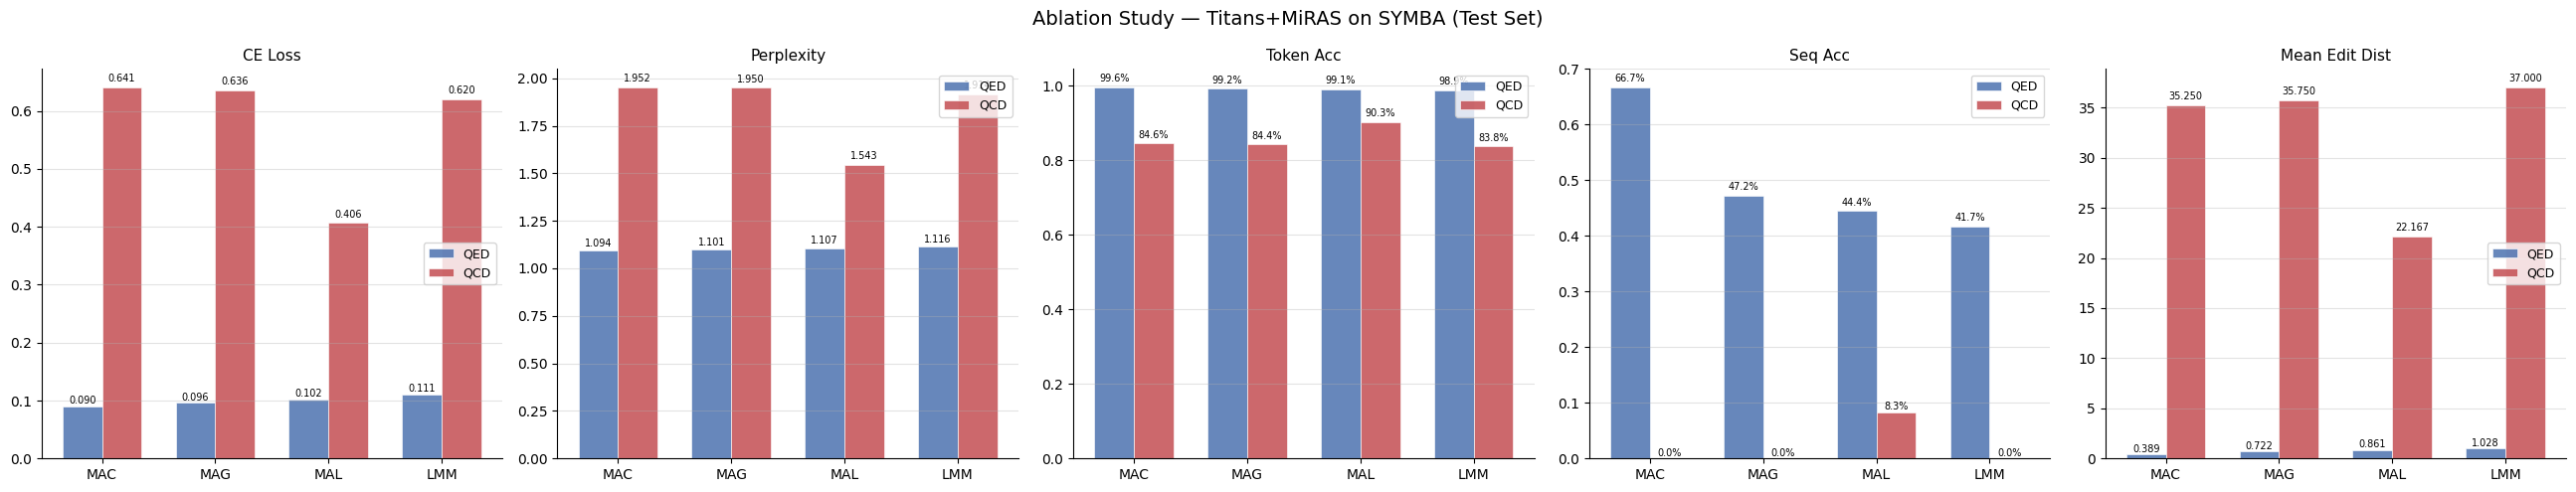

Bar charts saved.


In [ ]:
# ── Cell 12: Ablation bar charts (all metrics, QED vs QCD side by side) ───────
metrics   = ['ce_loss', 'ppl', 'tok_acc', 'seq_acc', 'mean_ed']
m_labels  = ['CE Loss', 'Perplexity', 'Token Acc', 'Seq Acc', 'Mean Edit Dist']
colors    = {'QED': '#4C72B0', 'QCD': '#C44E52'}
x         = np.arange(len(ARCHS))
width     = 0.35

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Ablation Study — Titans+MiRAS on SYMBA (Test Set)', fontsize=14)

for ax, metric, ml in zip(axes, metrics, m_labels):
    for li, lbl in enumerate(LABELS):
        vals = []
        for arch in ARCHS:
            key = f'{arch}_{lbl}'
            vals.append(ALL_RESULTS.get(key, {}).get(metric, 0))
        bars = ax.bar(x + li*width, vals, width,
                      label=lbl, color=colors[lbl], alpha=0.85,
                      edgecolor='white', linewidth=0.5)
        # Value labels on bars
        for bar, v in zip(bars, vals):
            fmt = f'{v*100:.1f}%' if 'acc' in metric else f'{v:.3f}'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vals)*0.01,
                    fmt, ha='center', va='bottom', fontsize=7)

    ax.set_title(ml, fontsize=11)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(ARCHS, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Bar charts saved.')

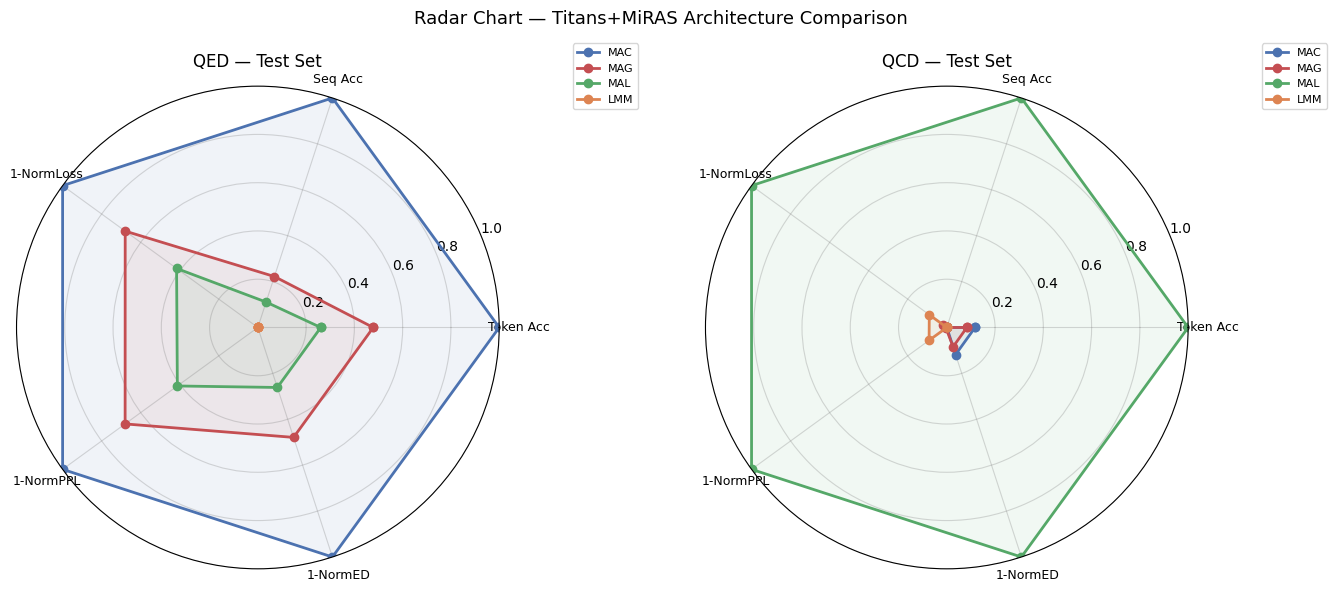

Radar chart saved.


In [ ]:
# ── Cell 13: Radar chart (all 4 archs, QED and QCD separately) ───────────────
def radar_chart(label, ax, title):
    cats   = ['Token Acc', 'Seq Acc', '1-NormLoss', '1-NormPPL', '1-NormED']
    N      = len(cats)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    # Normalise each metric to [0,1] across the 4 archs for this label
    rows = {arch: ALL_RESULTS.get(f'{arch}_{label}', {}) for arch in ARCHS}
    tok_accs  = [rows[a].get('tok_acc', 0)  for a in ARCHS]
    seq_accs  = [rows[a].get('seq_acc', 0)  for a in ARCHS]
    losses    = [rows[a].get('ce_loss', 1)  for a in ARCHS]
    ppls      = [rows[a].get('ppl', 1)      for a in ARCHS]
    eds       = [rows[a].get('mean_ed', 1)  for a in ARCHS]

    def norm_inv(vals):  # lower is better → invert after normalising
        mn, mx = min(vals), max(vals)
        if mx == mn: return [1.0]*len(vals)
        return [1 - (v-mn)/(mx-mn) for v in vals]

    def norm(vals):      # higher is better
        mn, mx = min(vals), max(vals)
        if mx == mn: return [1.0]*len(vals)
        return [(v-mn)/(mx-mn) for v in vals]

    arch_colors = ['#4C72B0','#C44E52','#55A868','#DD8452']
    for ai, arch in enumerate(ARCHS):
        values = [
            norm(tok_accs)[ai],
            norm(seq_accs)[ai],
            norm_inv(losses)[ai],
            norm_inv(ppls)[ai],
            norm_inv(eds)[ai],
        ]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2,
                label=arch, color=arch_colors[ai])
        ax.fill(angles, values, alpha=0.08, color=arch_colors[ai])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=12, pad=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    ax.grid(color='grey', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — Titans+MiRAS Architecture Comparison', fontsize=13)
radar_chart('QED', axes[0], 'QED — Test Set')
radar_chart('QCD', axes[1], 'QCD — Test Set')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved.')

In [ ]:
# ── Cell 15: Qualitative inference — all 4 archs × both labels ───────────────
# For each sample: show the amplitude, then all 4 arch predictions vs reference

def tokens_to_str(toks):
    no_space_before = {'}',')','*','/','.',',','^'}
    no_space_after  = {'(','{','*','/','^'}
    skip            = {'<PAD>','<BOS>','<EOS>','<SEP>','<TERM0>','<TERM1>','<UNK>'}
    toks = [t for t in toks if t not in skip]
    out  = ''
    for i, t in enumerate(toks):
        prev = toks[i-1] if i > 0 else ''
        sp   = (t not in no_space_before
                and prev not in no_space_after
                and i > 0)
        out += (' ' if sp else '') + t
    return out.strip()


def show_all_arch_predictions(label, n_samples=3, decode_method='greedy'):
    sv, tv  = vocabs[label]
    df      = test_dfs[label]
    cfg     = build_cfg(label)
    tgt_max = cfg['tgt_max_len']

    # print(f'\n{"#"*80}')
    print(f'  QUALITATIVE EXAMPLES — {label}  ({decode_method} decode)')
    # print(f'{"#"*80}')

    for idx in range(min(n_samples, len(df))):
        row     = df.iloc[idx]
        src_ids = [t for t in row['amp_ids']
                   if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]
        ref_ids = [t for t in row['sq_ids']
                   if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]
        ref_tok = tv.decode(ref_ids, include_special=False)
        ref_str = tokens_to_str(ref_tok)

        # Amplitude display (first 25 src tokens decoded via src vocab)
        amp_tok = sv.decode(src_ids[:25], include_special=False)
        amp_str = tokens_to_str(amp_tok)

        # print(f'\n{"─"*80}')
        print(f'  Sample {idx+1}  [{label}]')
        print(f'  AMP  : {amp_str} ...')
        print(f'  REF  : {ref_str[:120]} ...')
        print()

        for arch in ARCHS:
            key   = f'{arch}_{label}'
            model = MODELS[key]
            if model is None:
                print(f'  {arch:<4} : [no model]')
                continue

            if decode_method == 'beam':
                pred_ids = beam_decode(model, src_ids, tgt_max, beam_width=4)
            else:
                pred_ids = greedy_decode(model, src_ids, tgt_max)

            pred_tok = tv.decode(pred_ids, include_special=False)
            pred_str = tokens_to_str(pred_tok)
            ed       = editdistance.eval(pred_tok, ref_tok)
            match    = ' EXACT' if pred_tok == ref_tok else f' ed={ed}'

            print(f'  {arch:<4} [{match:^12}]: {pred_str[:110]} ...')

        print()


# Run for both labels
show_all_arch_predictions('QED', n_samples=3, decode_method='greedy')
show_all_arch_predictions('QCD', n_samples=3, decode_method='greedy')

  QUALITATIVE EXAMPLES — QED  (greedy decode)
  Sample 1  [QED]
  AMP  : - 4/9*i*e^2*(MOMENTUM_2_ % \ INDEX_0*gamma_{ % \ INDEX_1, % INDEX_2, ...
  REF  : 16/81*e^4*MOMENTUM_14*MOMENTUM_24*(MOMENTUM_13 + - 1/2*reg_prop)^(- 2) + 32/81*i*e^2*(i*e^2*m_c^2*(m_c^2 + 1/2*MOMENTUM_ ...

  MAC  [    ed=1    ]: 32/81*e^4*MOMENTUM_14*MOMENTUM_24*(MOMENTUM_13 + - 1/2*reg_prop)^(- 2) + 32/81*i*e^2*(i*e^2*m_c^2*(m_c^2 + 1/2 ...
  MAG  [    ed=17   ]: 32/81*e^4*MOMENTUM_14*MOMENTUM_34*(MOMENTUM_13 + - 1/2*reg_prop)^(- 2) + - 64/81*i*e^2*(i*e^2*m_c^2*(m_c^2 + - ...
  MAL  [    ed=2    ]: 32/81*e^4*MOMENTUM_14*MOMENTUM_24*(MOMENTUM_13 + - 1/2*reg_prop)^(- 2) + 2/81*i*e^2*(i*e^2*m_c^2*(m_c^2 + 1/2* ...
  LMM  [    ed=19   ]: 2*e^4*MOMENTUM_14*MOMENTUM_34*(MOMENTUM_23 + - 1/2*reg_prop)^(- 2) + (- 4)*i*e^2*(i*e^2*m_c^2*(m_c^2 + - 1/2*M ...

  Sample 2  [QED]
  AMP  : - 1/18*i*e^2*gamma_{ + % \ INDEX_0, % INDEX_1, % INDEX_2}*gamma_{ ...
  REF  : 1/324*e^4*(16*m_b^2*m_s^2 + (- 8)*m_b^2*MOMENTUM_13 + 8*MOME

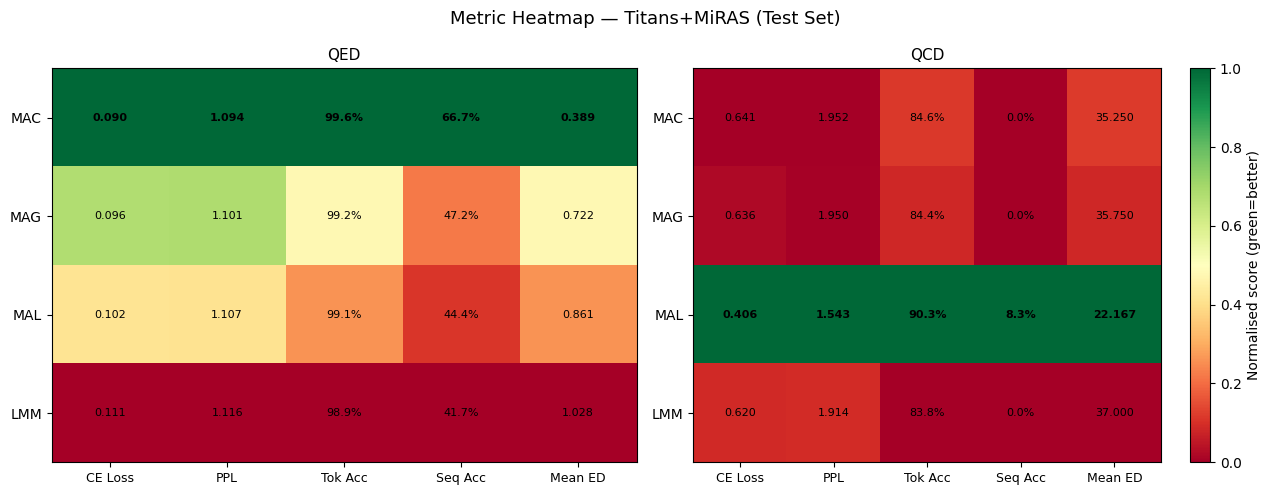

Heatmap saved.


In [ ]:
# ── Cell 16: Per-architecture heatmap (metrics × models) ─────────────────────
metric_cols = ['ce_loss','ppl','tok_acc','seq_acc','mean_ed']
col_labels  = ['CE Loss','PPL','Tok Acc','Seq Acc','Mean ED']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Metric Heatmap — Titans+MiRAS (Test Set)', fontsize=13)

for ax, lbl in zip(axes, LABELS):
    matrix = []
    for arch in ARCHS:
        key = f'{arch}_{lbl}'
        row = ALL_RESULTS.get(key, {})
        matrix.append([row.get(m, 0) for m in metric_cols])

    mat = np.array(matrix, dtype=float)

    # Normalise each column to [0,1] so colours are comparable
    mat_norm = mat.copy()
    for c in range(mat.shape[1]):
        mn, mx = mat[:,c].min(), mat[:,c].max()
        if mx > mn:
            mat_norm[:,c] = (mat[:,c]-mn) / (mx-mn)
        else:
            mat_norm[:,c] = 0.5

    # For loss / ppl / edit_dist: lower=better → invert colour
    invert_cols = [0, 1, 4]
    for c in invert_cols:
        mat_norm[:, c] = 1 - mat_norm[:, c]

    im = ax.imshow(mat_norm, cmap='RdYlGn', vmin=0, vmax=1,
                   aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(ARCHS)))
    ax.set_yticklabels(ARCHS, fontsize=10)
    ax.set_title(lbl, fontsize=11)

    # Annotate cells with raw values
    for r in range(len(ARCHS)):
        for c in range(len(metric_cols)):
            v   = mat[r, c]
            fmt = f'{v*100:.1f}%' if metric_cols[c] in ('tok_acc','seq_acc') \
                  else f'{v:.3f}'
            ax.text(c, r, fmt, ha='center', va='center',
                    fontsize=8, color='black',
                    fontweight='bold' if mat_norm[r,c] > 0.7 else 'normal')

plt.colorbar(im, ax=axes[-1], label='Normalised score (green=better)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

# ── Cell 17: Save all results to JSON + final summary print

In [ ]:
# ── Cell 17: Save all results to JSON + final summary print ──────────────────
# Save full results dict
with open(f'{OUT_DIR}/all_results.json', 'w') as f:
    json.dump(ALL_RESULTS, f, indent=2)

# Best model per label
print('\n' + '='*70)
print('  BEST MODELS PER PHYSICS MODEL (by CE Loss)')
print('='*70)
for lbl in LABELS:
    candidates = {k: v for k, v in ALL_RESULTS.items()
                  if v['label'] == lbl}
    if not candidates: continue
    best_key = min(candidates, key=lambda k: candidates[k]['ce_loss'])
    best     = candidates[best_key]
    print(f'\n  {lbl}:  Best = {best_key}')
    print(f'    CE Loss  : {best["ce_loss"]:.4f}')
    print(f'    PPL      : {best["ppl"]:.4f}')
    print(f'    Token Acc: {best["tok_acc"]*100:.2f}%')
    print(f'    Seq Acc  : {best["seq_acc"]*100:.2f}%')
    print(f'    Mean ED  : {best["mean_ed"]:.2f}')
    print(f'    Exact    : {best["exact_matches"]}/{best["total_samples"]}')

print('\n' + '='*70)
print('  FULL ABLATION TABLE')
print('='*70)
print(pretty.to_string(index=False))
print('='*70)
print(f'\nAll results saved to: {OUT_DIR}/')
print('  ablation_results.csv')
print('  ablation_results_pretty.csv')
print('  all_results.json')
print('  ablation_bar_charts.png')
print('  radar_chart.png')
print('  heatmap.png')
print('  curves_QED.png')
print('  curves_QCD.png')


  BEST MODELS PER PHYSICS MODEL (by CE Loss)

  QED:  Best = MAC_QED
    CE Loss  : 0.0896
    PPL      : 1.0936
    Token Acc: 99.58%
    Seq Acc  : 66.67%
    Mean ED  : 0.39
    Exact    : 24/36

  QCD:  Best = MAL_QCD
    CE Loss  : 0.4065
    PPL      : 1.5426
    Token Acc: 90.30%
    Seq Acc  : 8.33%
    Mean ED  : 22.17
    Exact    : 2/24

  FULL ABLATION TABLE
arch label ce_loss    ppl tok_acc seq_acc mean_ed  median_ed exact
 LMM   QCD  0.6197 1.9144  83.81%   0.00%   37.00       20.5  0/24
 MAC   QCD  0.6407 1.9515  84.57%   0.00%   35.25       20.5  0/24
 MAG   QCD  0.6360 1.9498  84.35%   0.00%   35.75       18.0  0/24
 MAL   QCD  0.4065 1.5426  90.30%   8.33%   22.17       11.5  2/24
 LMM   QED  0.1105 1.1164  98.89%  41.67%    1.03        1.0 15/36
 MAC   QED  0.0896 1.0936  99.58%  66.67%    0.39        0.0 24/36
 MAG   QED  0.0963 1.1009  99.22%  47.22%    0.72        1.0 17/36
 MAL   QED  0.1018 1.1070  99.07%  44.44%    0.86        1.0 16/36

All results saved to: 